# Advanced Hyperparameter Search With Random Forest

This notebook is a guided tour of the newer optimization controls available in `sklearn-genetic-opt` `0.13.0dev`. We will tune a `RandomForestClassifier` on the breast cancer dataset, inspect optimizer telemetry, compare against a lightweight randomized-search baseline, and then reuse the same ideas for feature selection.

## Menu

1. [Problem Setup](#problem-setup)
2. [Baseline Model](#baseline-model)
3. [Define a Genetic Search Space](#define-a-genetic-search-space)
4. [Configure GASearchCV](#configure-gasearchcv)
5. [Inspect Results and Telemetry](#inspect-results-and-telemetry)
6. [Compare With RandomizedSearchCV](#compare-with-randomizedsearchcv)
7. [Feature Selection With GAFeatureSelectionCV](#feature-selection-with-gafeatureselectioncv)
8. [Practical Takeaways](#practical-takeaways)

## Problem Setup

The breast cancer dataset is a binary classification task. It is small enough for a documentation example, but it still has enough numeric features to make model selection and feature selection meaningful.

We use a fixed train/test split and a shuffled `StratifiedKFold` so the notebook is reproducible.

In [1]:
import warnings
from pprint import pprint

import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from scipy.stats import randint

from sklearn_genetic import GAFeatureSelectionCV, GASearchCV
from sklearn_genetic.callbacks import ConsecutiveStopping, DeltaThreshold, TimerStopping
from sklearn_genetic.schedules import ExponentialAdapter, InverseAdapter
from sklearn_genetic.space import Categorical, Continuous, Integer

warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42

In [2]:
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

print(f"Training shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Positive class rate: {y.mean():.3f}")

Training shape: (398, 30)
Test shape: (171, 30)
Positive class rate: 0.627


## Baseline Model

Before tuning anything, train a plain random forest. This gives us a practical reference point: a genetic search should either improve the score, find a simpler configuration, or give us useful telemetry about the search process.

In [3]:
def evaluate_classifier(estimator, X_eval, y_eval):
    predictions = estimator.predict(X_eval)
    probabilities = estimator.predict_proba(X_eval)[:, 1]
    return {
        "accuracy": accuracy_score(y_eval, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_eval, predictions),
        "roc_auc": roc_auc_score(y_eval, probabilities),
    }


baseline = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)
baseline.fit(X_train, y_train)

baseline_metrics = evaluate_classifier(baseline, X_test, y_test)
baseline_metrics

{'accuracy': 0.935672514619883,
 'balanced_accuracy': 0.9297605140186915,
 'roc_auc': 0.991311331775701}

## Define a Genetic Search Space

`sklearn-genetic-opt` uses explicit search-space objects instead of sklearn parameter distributions. This keeps integer, continuous, and categorical choices clear.

In this example we tune both model capacity and split behavior. The search space is intentionally moderate so the notebook runs quickly.

In [4]:
param_grid = {
    "n_estimators": Integer(40, 140),
    "max_depth": Integer(2, 12),
    "min_samples_split": Integer(2, 12),
    "min_samples_leaf": Integer(1, 8),
    "max_features": Categorical(["sqrt", "log2", None]),
    "ccp_alpha": Continuous(0.0, 0.03),
}

## Configure GASearchCV

This configuration demonstrates several `0.13.0dev` options:

- `population_initializer="smart"` seeds a more useful initial population using estimator defaults, stratified categorical choices, and Latin hypercube sampling for numeric dimensions.
- `warm_start_configs` injects a known reasonable configuration into the first population.
- `parallel_backend="auto"` lets the estimator decide whether to parallelize candidate evaluation or cross-validation.
- `local_search=True` performs a short refinement around the best candidates at the end.
- `diversity_control=True` increases mutation pressure and can inject random candidates when the population collapses too early.
- `fitness_sharing=True` reduces crowding pressure so similar candidates do not dominate selection too soon.
- adaptive schedules let crossover and mutation probabilities evolve over generations.

In [5]:
callbacks = [
    DeltaThreshold(threshold=0.0005, generations=4, metric="fitness"),
    ConsecutiveStopping(generations=8, metric="fitness"),
    TimerStopping(total_seconds=120),
]

ga_search = GASearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    population_size=6,
    generations=4,
    crossover_probability=ExponentialAdapter(initial_value=0.8, end_value=0.4, adaptive_rate=0.15),
    mutation_probability=InverseAdapter(initial_value=0.25, end_value=0.05, adaptive_rate=0.2),
    tournament_size=3,
    elitism=True,
    keep_top_k=3,
    population_initializer="smart",
    warm_start_configs=[
        {
            "n_estimators": 100,
            "max_depth": 6,
            "min_samples_split": 4,
            "min_samples_leaf": 2,
            "max_features": "sqrt",
            "ccp_alpha": 0.0,
        }
    ],
    local_search=True,
    local_search_top_k=2,
    local_search_steps=1,
    local_search_radius=0.2,
    diversity_control=True,
    diversity_threshold=0.35,
    diversity_stagnation_generations=3,
    diversity_mutation_boost=1.8,
    random_immigrants_fraction=0.15,
    fitness_sharing=True,
    sharing_radius=0.35,
    sharing_alpha=1.0,
    n_jobs=-1,
    parallel_backend="auto",
    use_cache=True,
    verbose=True,
    return_train_score=False,
)

ga_search.fit(X_train, y_train, callbacks=callbacks)

gen	nevals	fitness 	fitness_std	fitness_max	fitness_min	population_size	unique_individuals	unique_individual_ratio	genotype_diversity	fitness_improvement	fitness_improved	stagnation_generations	best_generation	mutation_probability	diversity_control_triggered	random_immigrants	duplicate_replacements	local_refinements	fitness_sharing_applied	mean_niche_count	max_niche_count
0  	6     	0.986984	0.00145245 	0.989246   	0.984923   	6              	6                 	1                      	0.766667          	0                  	True            	0                     	0              	None                	False                      	0                	0                     	0                	False                  	0               	0              
1  	12    	0.986331	0.00215312 	0.988659   	0.983577   	6              	5                 	0.833333               	0.6               	-0.000587071       	False           	1                     	0              	0.2                 	False              

,estimator,RandomForestC...ndom_state=42)
,cv,StratifiedKFo... shuffle=True)
,param_grid,"{'ccp_alpha': <sklearn_gene...001894896B230>, 'max_depth': <sklearn_gene...001894895BB10>, 'max_features': <sklearn_gene...001894896B380>, 'min_samples_leaf': <sklearn_gene...001894898F230>, ...}"
,scoring,'roc_auc'
,population_size,6
,generations,4
,crossover_probability,<sklearn_gene...001894896B4D0>
,mutation_probability,<sklearn_gene...001894896B770>
,keep_top_k,3
,n_jobs,-1
,return_train_score,True


## Inspect Results and Telemetry

The usual sklearn-style attributes are available: `best_params_`, `best_score_`, and `best_estimator_`. The library also records optimization mechanics in `fit_stats_` and per-generation telemetry in `history`.

These fields are especially useful when tuning performance. If `cache_hits` is high, the search is revisiting candidates. If diversity collapses early, try stronger mutation, more random immigrants, a larger population, or fitness sharing.

In [6]:
print("Best CV ROC AUC:", round(ga_search.best_score_, 4))
print("Best parameters:")
pprint(ga_search.best_params_)

ga_metrics = evaluate_classifier(ga_search, X_test, y_test)
pd.DataFrame([baseline_metrics, ga_metrics], index=["baseline", "ga_search"])

Best CV ROC AUC: 0.9917
Best parameters:
{'ccp_alpha': 0.001757257030577965,
 'max_depth': 6,
 'max_features': 'log2',
 'min_samples_leaf': 4,
 'min_samples_split': 8,
 'n_estimators': 66}


,accuracy,balanced_accuracy,roc_auc
baseline,0.935673,0.929761,0.991311
ga_search,0.929825,0.925088,0.989048


In [7]:
ga_search.fit_stats_

{'evaluated_candidates': 56,
 'unique_candidates': 50,
 'cross_validate_calls': 50,
 'cache_hits': 6,
 'duplicate_candidates': 0,
 'skipped_invalid_candidates': 0,
 'population_parallel_batches': 6,
 'population_serial_batches': 0,
 'random_immigrants': 2,
 'local_refinement_candidates': 2}

In [8]:
history = pd.DataFrame(ga_search.history)
telemetry_columns = [
    "gen",
    "fitness",
    "fitness_max",
    "fitness_std",
    "unique_individual_ratio",
    "genotype_diversity",
    "stagnation_generations",
    "best_generation",
]
history[[column for column in telemetry_columns if column in history.columns]].tail()

,gen,fitness,fitness_max,fitness_std,unique_individual_ratio,genotype_diversity,stagnation_generations,best_generation
0,0,0.986984,0.989246,0.001452,1.000000,0.766667,0,0
1,1,0.986331,0.988659,0.002153,0.833333,0.600000,1,0
2,2,0.985122,0.986405,0.000723,0.666667,0.366667,2,0
3,3,0.986014,0.987173,0.001003,0.666667,0.500000,3,0
4,4,0.985986,0.987381,0.000944,0.666667,0.466667,4,0


A compact plot can make the search dynamics easier to read. The first chart shows the best fitness over time; the second chart shows diversity signals. If the diversity curves drop to zero early while fitness stops improving, the search is probably over-exploiting one region.

Text(0, 0.5, 'ROC AUC')

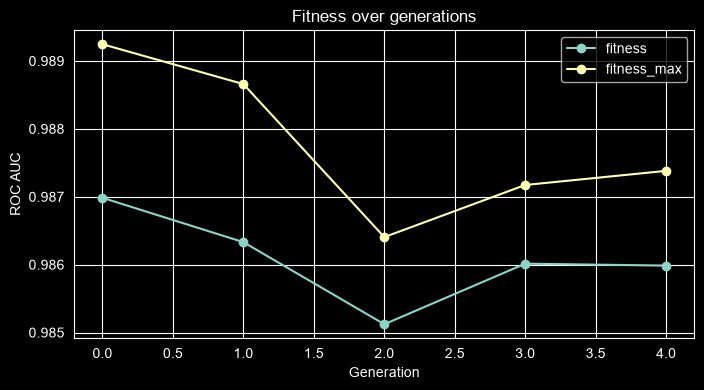

In [9]:
ax = history.plot(x="gen", y=["fitness", "fitness_max"], marker="o", figsize=(8, 4))
ax.set_title("Fitness over generations")
ax.set_xlabel("Generation")
ax.set_ylabel("ROC AUC")

Text(0, 0.5, 'Diversity')

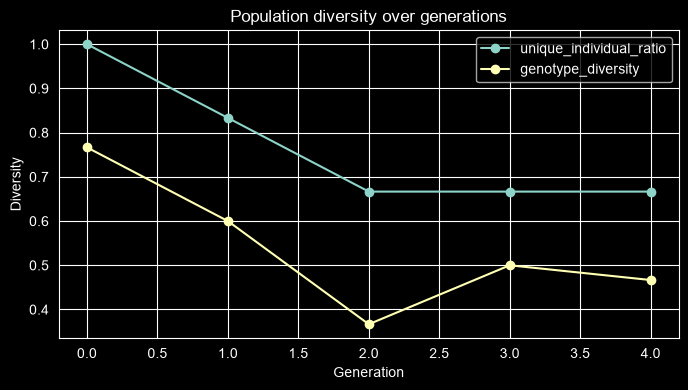

In [10]:
diversity_columns = [
    column
    for column in ["unique_individual_ratio", "genotype_diversity"]
    if column in history.columns
]

ax = history.plot(x="gen", y=diversity_columns, marker="o", figsize=(8, 4))
ax.set_title("Population diversity over generations")
ax.set_xlabel("Generation")
ax.set_ylabel("Diversity")

## Compare With RandomizedSearchCV

Genetic search is most useful when the search space is large, mixed-type, or expensive enough that exhaustive grids become unattractive. A lightweight `RandomizedSearchCV` baseline is still useful because it tells us whether the GA is paying for itself.

The parameter distributions below cover roughly the same region as the genetic search space, but they use sklearn/scipy objects instead of `sklearn-genetic-opt` dimensions.

In [11]:
randomized_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    param_distributions={
        "n_estimators": randint(40, 141),
        "max_depth": randint(2, 13),
        "min_samples_split": randint(2, 13),
        "min_samples_leaf": randint(1, 9),
        "max_features": ["sqrt", "log2", None],
        "ccp_alpha": np.linspace(0.0, 0.03, 20),
    },
    n_iter=12,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    refit=True,
)

randomized_search.fit(X_train, y_train)
randomized_metrics = evaluate_classifier(randomized_search, X_test, y_test)

pd.DataFrame(
    [baseline_metrics, randomized_metrics, ga_metrics],
    index=["baseline", "randomized_search", "ga_search"],
)

,accuracy,balanced_accuracy,roc_auc
baseline,0.935673,0.929761,0.991311
randomized_search,0.929825,0.925088,0.986419
ga_search,0.929825,0.925088,0.989048


## Feature Selection With GAFeatureSelectionCV

The same optimizer ideas can be used for feature selection. Here the individual is a binary mask instead of a hyperparameter vector.

`population_initializer="smart"` creates diverse masks with different numbers of selected features. `max_features` limits the largest valid mask. Invalid masks are skipped efficiently instead of spending cross-validation time on candidates whose fitness is already known to be invalid.

In [12]:
feature_selector = GAFeatureSelectionCV(
    estimator=RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=1,
        **ga_search.best_params_,
    ),
    scoring="roc_auc",
    cv=cv,
    population_size=8,
    generations=4,
    max_features=10,
    population_initializer="smart",
    local_search=True,
    local_search_top_k=2,
    local_search_steps=1,
    local_search_radius=0.15,
    diversity_control=True,
    diversity_threshold=0.30,
    random_immigrants_fraction=0.10,
    fitness_sharing=True,
    sharing_radius=0.40,
    n_jobs=-1,
    parallel_backend="auto",
    use_cache=True,
    verbose=True,
)

feature_selector.fit(X_train, y_train, callbacks=[TimerStopping(total_seconds=120)])

gen	nevals	fitness 	fitness_std	fitness_max	fitness_min	population_size	unique_individuals	unique_individual_ratio	genotype_diversity	fitness_improvement	fitness_improved	stagnation_generations	best_generation	mutation_probability	diversity_control_triggered	random_immigrants	duplicate_replacements	local_refinements	fitness_sharing_applied	mean_niche_count	max_niche_count
0  	8     	0.899605	0.116355   	0.98978    	0.693052   	8              	8                 	1                      	0.114286          	0                  	True            	0                     	0              	None                	False                      	0                	0                     	0                	False                  	0               	0              
1  	16    	0.933598	0.0882384  	0.989093   	0.711197   	8              	6                 	0.75                   	0.104762          	-0.00068679        	False           	1                     	0              	0.8                 	True               

,estimator,RandomForestC...ndom_state=42)
,cv,StratifiedKFo... shuffle=True)
,scoring,'roc_auc'
,population_size,8
,generations,4
,max_features,10
,n_jobs,-1
,local_search,True
,local_search_top_k,2
,local_search_radius,0.15
,diversity_control,True


In [13]:
selected_features = X_train.columns[feature_selector.support_]
print(f"Selected {len(selected_features)} features:")
print(selected_features.tolist())

selector_metrics = evaluate_classifier(feature_selector, X_test, y_test)
pd.DataFrame(
    [baseline_metrics, randomized_metrics, ga_metrics, selector_metrics],
    index=["baseline", "randomized_search", "ga_search", "feature_selector"],
)

Selected 9 features:
['mean compactness', 'mean symmetry', 'area error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst concave points', 'worst symmetry']


,accuracy,balanced_accuracy,roc_auc
baseline,0.935673,0.929761,0.991311
randomized_search,0.929825,0.925088,0.986419
ga_search,0.929825,0.925088,0.989048
feature_selector,0.941520,0.934433,0.987588


In [14]:
print(classification_report(y_test, feature_selector.predict(X_test), target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.94      0.91      0.92        64
      benign       0.94      0.96      0.95       107

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171



## Practical Takeaways

- Start with `population_initializer="smart"`; it usually gives better early coverage than random initialization.
- Use `fit_stats_` to understand the cost of the run: evaluated candidates, unique candidates, cache hits, skipped invalid masks, and cross-validation calls.
- Use `history` to decide whether the optimizer is exploring enough. Low diversity plus stalled fitness suggests stronger mutation, fitness sharing, random immigrants, or a larger population.
- Use `local_search=True` when the GA already finds good regions and you want a final exploitation pass.
- Keep a sklearn baseline such as `RandomizedSearchCV` nearby. It is the simplest way to check whether a more advanced optimizer is improving quality enough to justify extra search time.